In [5]:
import pandas as pd
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline

label_case = 'label_cutoff_20%' # label_cutoff_50%, label_cutoff_20%

RANDOM_STATE = 42

In [ ]:

# --- Δεδομένα: όλα τα 1157 μόρια, όλοι οι descriptors μετά τον καθαρισμό ---
df = pd.read_csv(f'../Data/descriptors_after_correlation_{label_case}.csv')
labels = pd.read_csv('../Data/labels.csv')
merged = df.merge(labels[['SMILES', label_case]], on='SMILES')

X = merged.drop(columns=['SMILES', label_case])
y = merged[label_case].astype(int).values
print(f"Μόρια: {len(y)}, descriptors: {X.shape[1]}")

# --- Elastic Net ---
pipe = Pipeline([
    ('scaler', RobustScaler()),
    ('model', LogisticRegressionCV(
        penalty='elasticnet', solver='saga', class_weight='balanced',
        l1_ratios=[0.3, 0.5, 0.7, 0.9], Cs=10, cv=5, scoring='roc_auc',
        max_iter=10000, tol=1e-3, random_state=RANDOM_STATE))
])
pipe.fit(X, y)

best = pipe.named_steps['model']
coefs = pd.Series(best.coef_.ravel(), index=X.columns)
print(f"C={best.C_[0]:.4f}, l1_ratio={best.l1_ratio_[0]}")

# --- Επιλεγμένοι descriptors = οι μη μηδενικοί συντελεστές ---
selected = coefs[coefs != 0].abs().sort_values(ascending=False).index.tolist()
print(f"Επιλεγμένοι descriptors: {len(selected)} / {len(coefs)}")

# --- Αποθήκευση ---
X_final = X[selected].copy()
X_final.insert(0, 'SMILES', merged['SMILES'])
X_final.to_csv(f'../Data/elasticnet_features_allmol_{label_case}.csv', index=False)

# Οι συντελεστές, ταξινομημένοι
coef_table = pd.DataFrame({'descriptor': selected, 'coef': coefs[selected].values})
coef_table.to_csv(f'../Data/elasticnet_coefficients_allmol_{label_case}.csv', index=False)
print(coef_table.head(20).to_string(index=False))

Μόρια: 1142, descriptors: 721
C=21.5443, l1_ratio=0.3
Επιλεγμένοι descriptors: 721 / 721
 descriptor      coef
     MINsCl  0.078304
      WPSA2 -0.053654
    AATSC7m  0.043174
      WPSA3 -0.039354
     Xc-4dv -0.037692
    ATSC1se  0.037600
     SsssCH  0.036213
    AATSC7s -0.035366
      FPSA2 -0.034896
      C3SP3  0.033816
      PPSA3 -0.032243
      nBase -0.031833
  PEOE_VSA4  0.030333
    ATSC8se -0.029684
   BCUTi-1l  0.028264
EState_VSA8 -0.027702
      MINsF  0.027644
    MDEO-11 -0.027098
      PPSA4 -0.026353
 SlogP_VSA7  0.025791


In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score


df = pd.read_csv(f'../Data/descriptors_after_correlation_{label_case}.csv')
labels = pd.read_csv('../Data/labels.csv')
merged = df.merge(labels[['SMILES', label_case]], on='SMILES')

X = merged.drop(columns=['SMILES', label_case])
y = merged[label_case].astype(int).values

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def make_pipe(C, l1_ratio):
    return Pipeline([
        ('scaler', RobustScaler()),
        ('model', LogisticRegression(
            penalty='elasticnet', solver='saga', class_weight='balanced',
            C=C, l1_ratio=l1_ratio, max_iter=5000, tol=1e-3,
            random_state=RANDOM_STATE))
    ])

print(f"{'C':>10} {'l1_ratio':>9} {'descriptors':>12} {'ROC-AUC':>9}")
print("-" * 44)
for l1_ratio in [0.7, 0.9, 1.0]:
    for C in [0.001, 0.003, 0.01, 0.03, 0.1]:
        pipe = make_pipe(C, l1_ratio)
        pipe.fit(X, y)
        n = int((pipe.named_steps['model'].coef_.ravel() != 0).sum())
        auc = cross_val_score(pipe, X, y, cv=cv, scoring='roc_auc').mean()
        print(f"{C:>10.4f} {l1_ratio:>9} {n:>12} {auc:>9.4f}")

         C  l1_ratio  descriptors   ROC-AUC
--------------------------------------------
    0.0010       0.7            3    0.5534
    0.0030       0.7            5    0.5776
    0.0100       0.7           28    0.6458
    0.0300       0.7          141    0.6861
    0.1000       0.7          415    0.6911
    0.0010       0.9            3    0.5544
    0.0030       0.9            4    0.5521
    0.0100       0.9           13    0.6315
    0.0300       0.9          106    0.6817
    0.1000       0.9          347    0.6909
    0.0010       1.0            3    0.5546
    0.0030       1.0            4    0.5573
    0.0100       1.0           10    0.6265
    0.0300       1.0           92    0.6804
    0.1000       1.0          318    0.6912


Elastic Net: C=0.1, l1_ratio=1.0, 5-fold ROC-AUC=0.7052
Δεξαμενή μετά τον καθαρισμό : 721
----------------------------------------------
Elastic Net                 :  346
MI ∩ CatBoost               :  232
Κοινοί                      :  131
Μόνο Elastic Net            :  215
Μόνο MI ∩ CatBoost          :  101
Σε καμία από τις δύο        :  274
Jaccard                     :   0.293


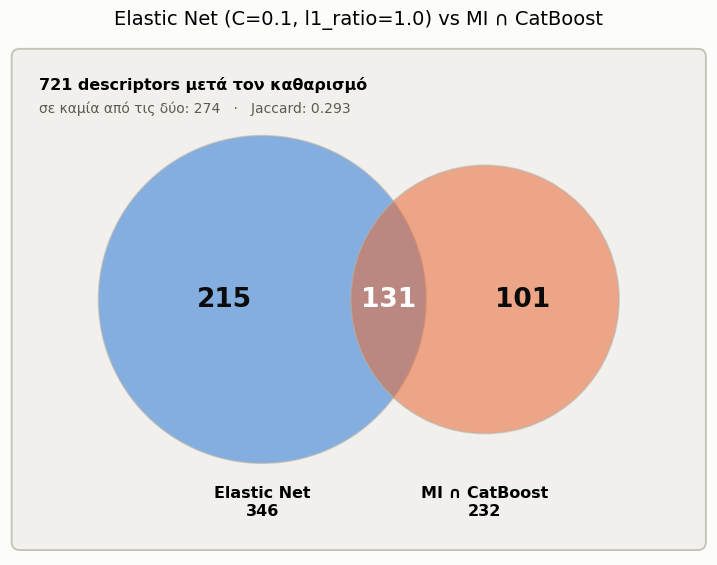


Αποθηκεύτηκαν:
  ../Data/elasticnet_selected_cutoff20.csv        (346 descriptors)
  ../Data/feature_overlap_en_vs_mi_cutoff20.csv
  elasticnet_vs_243_pool_venn_cutoff20.png


In [6]:
# --- Σύγκριση των δύο μεθόδων επιλογής, με βάση τον πίνακα του προηγούμενου κελιού ---
# Διάλεξε C και l1_ratio από τον πίνακα· το κελί ξανατρέχει το elastic net με αυτές
# τις τιμές και συγκρίνει το σύνολο που προκύπτει με το MI ∩ CatBoost.
EN_C        = 0.1
EN_L1_RATIO = 1.0
SHOW_AUC    = True     # False = παράλειψη του 5-fold CV (πιο γρήγορο)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score

# ---------------------------------------------------------------- δεδομένα
_df     = pd.read_csv(f'../Data/descriptors_after_correlation_{label_case}.csv')
_labels = pd.read_csv('../Data/labels.csv')
_merged = _df.merge(_labels[['SMILES', label_case]], on='SMILES')

X_pool = _merged.drop(columns=['SMILES', label_case])
y_pool = _merged[label_case].astype(int).values
pool_features = X_pool.columns.tolist()
TOTAL = len(pool_features)

# ------------------------------------------------- elastic net με τις επιλεγμένες τιμές
en_pipe = Pipeline([
    ('scaler', RobustScaler()),
    ('model', LogisticRegression(
        penalty='elasticnet', solver='saga', class_weight='balanced',
        C=EN_C, l1_ratio=EN_L1_RATIO, max_iter=5000, tol=1e-3,
        random_state=RANDOM_STATE))
])
en_pipe.fit(X_pool, y_pool)

en_coefs = pd.Series(en_pipe.named_steps['model'].coef_.ravel(), index=pool_features)
en_set   = en_coefs[en_coefs != 0].abs().sort_values(ascending=False).index.tolist()

en_auc = (cross_val_score(en_pipe, X_pool, y_pool, scoring='roc_auc',
                          cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)).mean()
          if SHOW_AUC else np.nan)

# ---------------------------------------------------------- το σύνολο MI ∩ CatBoost
_mi = pd.read_excel(f'../Data/final_dataset_{label_case}.xlsx', sheet_name='Dataset', nrows=1)
mi_set = [c for c in _mi.columns if c not in ('SMILES', 'smile')]

# Filter MI set to only include features that exist in the pool
assert set(mi_set) <= set(pool_features), "Το MI ∩ CatBoost δεν είναι υποσύνολο του pool"

# ------------------------------------------------------------------- σύγκριση
en_s, mi_s = set(en_set), set(mi_set)
common    = sorted(en_s & mi_s)
only_en   = sorted(en_s - mi_s)
only_mi   = sorted(mi_s - en_s)
neither   = TOTAL - len(en_s | mi_s)
jaccard   = len(common) / len(en_s | mi_s) if (en_s | mi_s) else 0.0

print(f"Elastic Net: C={EN_C}, l1_ratio={EN_L1_RATIO}"
      + (f", 5-fold ROC-AUC={en_auc:.4f}" if SHOW_AUC else ""))
print(f"Δεξαμενή μετά τον καθαρισμό : {TOTAL}")
print("-" * 46)
print(f"Elastic Net                 : {len(en_s):>4}")
print(f"MI ∩ CatBoost               : {len(mi_s):>4}")
print(f"Κοινοί                      : {len(common):>4}")
print(f"Μόνο Elastic Net            : {len(only_en):>4}")
print(f"Μόνο MI ∩ CatBoost          : {len(only_mi):>4}")
print(f"Σε καμία από τις δύο        : {neither:>4}")
print(f"Jaccard                     : {jaccard:>7.3f}")

if not (mi_s <= set(pool_features)):
    missing_features = mi_s - set(pool_features)
    print(f"\nΠροσοχή: {len(missing_features)} χαρακτηριστικά από MI δεν υπάρχουν στη δεξαμενή:")
    print(f"  {sorted(missing_features)[:10]}{'...' if len(missing_features) > 10 else ''}")

# ----------------------------------------------------- area-proportional Venn
def _lens_area(d, r1, r2):
    """Εμβαδόν τομής δύο κύκλων ακτίνας r1, r2 με απόσταση κέντρων d."""
    if d >= r1 + r2:
        return 0.0
    if d <= abs(r1 - r2):
        return np.pi * min(r1, r2) ** 2
    a1 = r1**2 * np.arccos((d**2 + r1**2 - r2**2) / (2 * d * r1))
    a2 = r2**2 * np.arccos((d**2 + r2**2 - r1**2) / (2 * d * r2))
    a3 = 0.5 * np.sqrt((-d + r1 + r2) * (d + r1 - r2) * (d - r1 + r2) * (d + r1 + r2))
    return a1 + a2 - a3

n1, n2, nc = len(en_s), len(mi_s), len(common)
SCALE = 1.0 / np.sqrt(max(n1, n2))          # ο μεγαλύτερος κύκλος να έχει ακτίνα 1
r1 = np.sqrt(n1 / np.pi) * SCALE * np.sqrt(np.pi)
r2 = np.sqrt(n2 / np.pi) * SCALE * np.sqrt(np.pi)

# δυαδική αναζήτηση της απόστασης που δίνει τη σωστή επικάλυψη
target = nc * SCALE**2
lo, hi = abs(r1 - r2), r1 + r2
for _ in range(80):
    mid = (lo + hi) / 2
    if _lens_area(mid, r1, r2) > target:
        lo = mid
    else:
        hi = mid
d = (lo + hi) / 2

cx1, cx2 = -d / 2, d / 2

fig, ax = plt.subplots(figsize=(9, 7.2), facecolor='#fcfcfb')
ax.set_facecolor('#fcfcfb')

# η δεξαμενή
pad = 0.42
box_w = (cx2 + r2) - (cx1 - r1) + 2 * pad
box_h = 2 * max(r1, r2) + 2 * pad
box_x = cx1 - r1 - pad
box_y = -max(r1, r2) - pad
ax.add_patch(FancyBboxPatch((box_x, box_y), box_w, box_h,
                            boxstyle="round,pad=0.11,rounding_size=0.05",
                            linewidth=1.3, edgecolor='#c3c2b7',
                            facecolor='#f1f0ec', zorder=0))

ax.add_patch(Circle((cx1, 0), r1, facecolor='#2a78d6', alpha=0.55,
                    edgecolor='#b5b3ab', linewidth=1.2, zorder=2))
ax.add_patch(Circle((cx2, 0), r2, facecolor='#eb6834', alpha=0.55,
                    edgecolor='#b5b3ab', linewidth=1.2, zorder=2))

# αριθμοί στις τρεις περιοχές
lens_l, lens_r = max(cx1 - r1, cx2 - r2), min(cx1 + r1, cx2 + r2)
pos = {
    'only_en': ((cx1 - r1 + lens_l) / 2, 0, len(only_en), '#0b0b0b'),
    'common':  ((lens_l + lens_r) / 2,   0, len(common),  '#ffffff'),
    'only_mi': ((lens_r + cx2 + r2) / 2, 0, len(only_mi), '#0b0b0b'),
}
for _, (px, py, val, col) in pos.items():
    ax.text(px, py, str(val), fontsize=19, fontweight='bold',
            ha='center', va='center', color=col, zorder=4)

ax.text(box_x + 0.06, box_y + box_h - 0.06,
        f'{TOTAL} descriptors μετά τον καθαρισμό',
        fontsize=11.5, fontweight='semibold', va='top', zorder=5)
ax.text(box_x + 0.06, box_y + box_h - 0.21,
        f'σε καμία από τις δύο: {neither}   ·   Jaccard: {jaccard:.3f}',
        fontsize=10, color='#5c5a54', va='top', zorder=5)

y_lab = -max(r1, r2) - 0.14
ax.text(cx1, y_lab, f'Elastic Net\n{len(en_s)}', fontsize=11.5,
        fontweight='semibold', ha='center', va='top', zorder=5)
ax.text(cx2, y_lab, f'MI ∩ CatBoost\n{len(mi_s)}', fontsize=11.5,
        fontweight='semibold', ha='center', va='top', zorder=5)

ax.set_xlim(box_x - 0.12, box_x + box_w + 0.12)
ax.set_ylim(y_lab - 0.42, box_y + box_h + 0.12)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title(f'Elastic Net (C={EN_C}, l1_ratio={EN_L1_RATIO}) vs MI ∩ CatBoost',
             fontsize=14, pad=16)

_tag = label_case.replace('label_cutoff_', '').replace('%', '')
plt.savefig(f'elasticnet_vs_243_pool_venn_cutoff{_tag}.png', dpi=200,
            bbox_inches='tight', facecolor='#fcfcfb')
plt.show()

# ------------------------------------------------------------------ αποθήκευση
pd.Series(en_set, name='descriptor').to_csv(
    f'../Data/elasticnet_selected_cutoff{_tag}.csv', index=False)

pd.DataFrame({
    'descriptor': common + only_en + only_mi,
    'ομάδα': (['κοινός'] * len(common) + ['μόνο ElasticNet'] * len(only_en)
              + ['μόνο MI ∩ CatBoost'] * len(only_mi)),
    'en_coef': ([en_coefs[d] for d in common] + [en_coefs[d] for d in only_en]
                + [en_coefs.get(d, 0.0) for d in only_mi]),
}).to_csv(f'../Data/feature_overlap_en_vs_mi_cutoff{_tag}.csv', index=False)

print(f"\nΑποθηκεύτηκαν:")
print(f"  ../Data/elasticnet_selected_cutoff{_tag}.csv        ({len(en_set)} descriptors)")
print(f"  ../Data/feature_overlap_en_vs_mi_cutoff{_tag}.csv")
print(f"  elasticnet_vs_243_pool_venn_cutoff{_tag}.png")
